# 6. Paper figures

The figures for a paper on the forced response: the **main figures** put the models together, and the **supplementary figures** show each model. They are drawn from what notebook 03 saved, with the same colour scales as notebook 04, in print style: 6.5–8 pt text, every figure 183 mm (7.2 in) wide (a two-column page), panel letters, and no titles (the caption above each figure is its title). *Check the colour ranges* says whether the scales suit the data. Each is saved as a PDF (vector) and a 300 dpi PNG in `figures/<variable>/paper/`.

| Figure | What it shows |
|---|---|
| 1 | The distribution, after Bracegirdle et al. (2024, Fig. 1): Q05, the mean, Q95 and the width in hist-nat and historical, and the change in each (multi-model median), in winter (JJA) |
| 2, 3 | How each forcing changes the distribution: the bottom row of Fig. 1 for every forcing, in winter (JJA) and summer (DJF) |
| 4 | Where the mean and the width have changed together, every forcing and both seasons, on one 3 × 3 colour key |
| 5 | Area means south of 60°S: every model's change in the mean and in the width, every forcing and season |
| 6 | The change at each latitude (after Bracegirdle et al., 2024, Fig. 2), every model as a line, with the sea-ice edge (JJA) |
| S1 | Fig. 1 in summer (DJF) |
| S2, S3 | Fig. 2 and 3 for every model on its own (historical) |
| S4–S7 | How many models have a significant change in the mean, and in the width (DJF, JJA) |
| S8, S9 | S/N of every model (DJF, JJA) |
| S10 | The change at every 5th percentile, every model (DJF, JJA) |
| S11 | Additivity: historical against the sum of the single forcings, every model (JJA) |
| S12 | Fig. 6 in summer (DJF) |

**Putting the models together.** A multi-model panel is the median across models. A change is **robust** where at least two-thirds of the models (`ROBUST`, `config.SIGNIFICANT_THRESHOLD`) have a significant change of the same sign (the IPCC AR6 approach); dots mark where it is not. The tests are those of notebook 03: the member-block test for the mean, the hist-nat bootstrap for the width (of the internal variability); single quantiles have no test.

Names end in their type: `_tree` (DataTree), `_ds` (Dataset), `_da` (DataArray), `_arr` (numpy array), `_df` (DataFrame).

## Setup

In [1]:
import sys
sys.path[:0] = ['..']   # this repository: the extant package and plotting_modules

import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from extant import config, paths, response_change as rc, sea_ice, significance as sig, storage, zonal
from extant.logger import setup_logging
from extant.plots import forced_response as fr, zonal as zp

logger = setup_logging('extant', logging.INFO)
xr.set_options(display_expand_attrs=False, display_expand_data=False)

In [2]:
%matplotlib inline

## Settings

In [3]:
VARIABLE = 'tas'
var = config.VARIABLES[VARIABLE]
UNITS = var.units
WINDOW = config.WINDOW

#(t): The forcings, in the order of every figure; the seasons; and the winter and summer of the main figures
EXPERIMENTS = ['hist-GHG', 'hist-aer', 'hist-totalO3', 'historical']
SEASONS = ['DJF', 'MAM', 'JJA', 'SON']
WINTER, SUMMER = 'JJA', 'DJF'

#(t): Significance level of every test; |S/N| counted as emerged; the fraction of models that makes a change robust
ALPHA = 0.05
SN_THRESHOLD = 2
ROBUST = config.SIGNIFICANT_THRESHOLD

#(t): The test of the mean, as in notebook 04 section 5: 'significant' is the member-block test
MEAN_TEST = 'significant'

#(t): Print style; the width of every figure, a two-column page (183 mm, which each figure's panels fill); and the
#(t): most a map figure can be tall (229 mm: its panels shrink to fit, leaving room for the caption)
STYLE = fr.PAPER
WIDTH = fr.PAGE_WIDTH
HEIGHT = fr.PAGE_HEIGHT


def result_path(name):
    """Where notebook 03 saved a result: results/<variable>/<run>/<name>.zarr."""
    return paths.result(name, VARIABLE, RUN)

In [4]:
#(t): The same colour scales as notebook 04
scales = fr.colour_scales(VARIABLE, alpha=ALPHA)

## Open the saved results

Run **one** of the next two sections. Both leave `RUN`, which says which saved results to open, and `PAPER_DIR`, where the figures go.

### Sample data

In [5]:
RUN = 'sample'
PAPER_DIR = paths.figure('paper_sample', VARIABLE)
PAPER_DIR

PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper_sample')

### Full data (JASMIN)

In [6]:
RUN = 'full'
PAPER_DIR = paths.figure('paper', VARIABLE)
PAPER_DIR

PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper')

### The saved results

In [7]:
final_mean_ds = storage.open_dataset(result_path('final_mean'), load=True)
mean_block_ds = storage.open_dataset(result_path('mean_block'), load=True)
lesfmip_seasonal_sn_ds = storage.open_dataset(result_path('sn'), load=True)
q_histnat_base_ds = storage.open_dataset(result_path('q_histnat_base'), load=True)
final_q_da = storage.open_dataarray(result_path('final_quantiles'), load=True)
quantile_curve_da = storage.open_dataarray(result_path('quantile_curve'), load=True)
qrange_change_ds = storage.open_dataset(result_path('qrange_change'), load=True)
tails_ds = storage.open_dataset(result_path('tails'), load=True)
own_changes_da = storage.open_dataarray(result_path('own_changes'), load=True)
zonal_mean_ds = storage.open_dataset(result_path('zonal_mean_test'), load=True)
zonal_width_ds = storage.open_dataset(result_path('zonal_width_test'), load=True)

13:31:25 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/final_mean.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


13:31:32 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/mean_block.zarr
13:31:32 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/sn.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

13:31:33 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/q_histnat_base.zarr
13:31:33 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/final_quantiles.zarr
13:31:33 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/quantile_curve.zarr
13:31:33 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/qrange_change.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

13:31:33 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/tails.zarr
13:31:34 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/own_changes.zarr
13:31:34 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/zonal_mean_test.zarr
13:31:34 INFO    extant.storage | opening /work/scratch-pw4/aborow/ExtAnt/results/tas/full/zonal_width_test.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be suppor

In [8]:
#(t): The models: every count runs up to this many
N_MODELS = mean_block_ds.sizes['model']
list(mean_block_ds['model'].values)

['CanESM5',
 'GISS-E2-1-G',
 'HadGEM3-GC31-LL',
 'MIROC6',
 'MPI-ESM1-2-LR',
 'NorESM2-LM']

### Sea ice

For the ice edge in Figs 6 and S12 (notebook 01, section 5). Run **one** of the next two sections.

#### Without sea ice

In [9]:
ice_edges_da = None

#### With sea ice (JASMIN)

In [10]:
ice_extents_tree = storage.open_tree(paths.result('extent', 'siconc', 'full'), load=True)
ice_edges_da = sea_ice.edge_latitude(ice_extents_tree, years=WINDOW)

FileNotFoundError: results/siconc/full/extent.zarr is in neither DATA_DIR nor SCRATCH. Looked for:
  /gws/ssde/j25b/leader_epesc/aborow/ExtAnt/results/siconc/full/extent.zarr  (folder does not exist)
  /work/scratch-pw4/aborow/ExtAnt/results/siconc/full/extent.zarr  (folder does not exist)

## The fields

As in notebook 04, section 5: each part of the distribution in hist-nat and in every experiment, the change in each, and which changes are significant in each model.

In [11]:
#(t): S/N in the centre of the final WINDOW years, for the 'emerged' and 'robust' mean tests
sn_final_da = lesfmip_seasonal_sn_ds[VARIABLE].isel(year=config.LAST_FULL_YEAR)
sn_final_da

<xarray.DataArray 'tas' (model: 6, experiment: 5, season: 4, lat: 20, lon: 144)> Size: 3MB
2.653 2.655 2.657 2.659 2.664 2.669 ... 1.513 1.457 1.342 1.213 1.28 0.8197
Coordinates:
    year        int64 8B 2003
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

In [12]:
#(t): |S/N|: how far apart the distributions have moved, whichever way (figures S8 and S9)
abs_sn_final_da = np.abs(sn_final_da)

In [13]:
#(t): Every change and its test, on (model, experiment, season, lat, lon)
change_ds = rc.change_summary(mean_block_ds['mean_change'], mean_block_ds['pvalue'], sn_final_da, qrange_change_ds,
                              tails_ds, alpha=ALPHA, sn_threshold=SN_THRESHOLD)
change_ds

<xarray.Dataset> Size: 24MB
Dimensions:            (model: 6, season: 4, lat: 20, experiment: 4, lon: 144)
Coordinates:
  * model              (model) object 48B 'CanESM5' ... 'NorESM2-LM'
  * season             (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat                (lat) float64 160B -87.5 -85.0 -82.5 ... -42.5 -40.0
  * experiment         (experiment) object 32B 'hist-GHG' ... 'historical'
  * lon                (lon) float64 1kB -180.0 -177.5 -175.0 ... 175.0 177.5
Data variables: (12/15)
    mean_change        (lat, lon, season, model, experiment) float32 1MB 2.33...
    mean_pvalue        (lat, lon, season, model, experiment) float64 2MB 0.00...
    signal_to_noise    (model, experiment, season, lat, lon) float64 2MB 2.65...
    width_change       (lat, lon, season, model, experiment) float64 2MB -0.0...
    width_pvalue       (lat, lon, season, model, experiment) float64 2MB 0.93...
    tail_asymmetry     (lat, lon, season, model, experiment) float64 2MB 0.00...
    ...                 ...
    lower_tail_change  (lat, lon, season, model, experiment) float64 2MB -0.0...
    q95_change         (lat, lon, season, model, experiment) float64 2MB 0.01...
    mean_significant   (lat, lon, season, model, experiment) bool 276kB True ...
    mean_emerged       (model, experiment, season, lat, lon) bool 276kB True ...
    mean_robust        (lat, lon, season, model, experiment) bool 276kB True ...
    width_significant  (lat, lon, season, model, experiment) bool 276kB False...
Attributes: (2)

In [14]:
#(t): hist-nat's distribution: Q05 and Q95 over its whole record, the mean over the final WINDOW years, and the
#(t): width of its internal variability
hist_nat_fields_ds = xr.Dataset({
    'Q05': q_histnat_base_ds[VARIABLE].sel(quantile=0.05, drop=True),
    'Mean': final_mean_ds[VARIABLE].sel(experiment='hist-nat', drop=True),
    'Q95': q_histnat_base_ds[VARIABLE].sel(quantile=0.95, drop=True),
    'Q95 − Q05': qrange_change_ds['hist_nat_qrange'],
})
hist_nat_fields_ds

<xarray.Dataset> Size: 2MB
Dimensions:    (lat: 20, lon: 144, model: 6, season: 4)
Coordinates:
  * lat        (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * lon        (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * model      (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    Q05        (lat, lon, season, model) float64 553kB -28.47 -32.94 ... 13.13
    Mean       (lat, lon, season, model) float32 276kB -27.12 -30.91 ... 13.83
    Q95        (lat, lon, season, model) float64 553kB -25.6 -28.9 ... 14.55
    Q95 − Q05  (lat, lon, season, model) float64 553kB 2.882 4.027 ... 1.42

In [15]:
#(t): Every experiment's, over its final WINDOW years
experiment_fields_ds = xr.Dataset({
    'Q05': final_q_da.sel(quantile=0.05, drop=True),
    'Mean': final_mean_ds[VARIABLE].drop_sel(experiment='hist-nat'),
    'Q95': final_q_da.sel(quantile=0.95, drop=True),
    'Q95 − Q05': qrange_change_ds['experiment_qrange'],
})
experiment_fields_ds

<xarray.Dataset> Size: 8MB
Dimensions:     (model: 6, lat: 20, season: 4, lon: 144, experiment: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
Data variables:
    Q05         (lat, lon, season, model, experiment) float64 2MB -26.2 ... 1...
    Mean        (lat, lon, season, model, experiment) float32 1MB -24.78 ... ...
    Q95         (lat, lon, season, model, experiment) float64 2MB -23.32 ... ...
    Q95 − Q05   (lat, lon, season, model, experiment) float64 2MB 2.849 ... 1...

In [16]:
#(t): The change in each
change_fields_ds = experiment_fields_ds - hist_nat_fields_ds
change_fields_ds

<xarray.Dataset> Size: 8MB
Dimensions:     (model: 6, lat: 20, season: 4, lon: 144, experiment: 4)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
Data variables:
    Q05         (lat, lon, season, model, experiment) float64 2MB 2.27 ... 0....
    Mean        (lat, lon, season, model, experiment) float32 1MB 2.339 ... 0...
    Q95         (lat, lon, season, model, experiment) float64 2MB 2.28 ... 0....
    Q95 − Q05   (lat, lon, season, model, experiment) float64 2MB -0.03293 .....

In [17]:
#(t): Which changes are significant in each model: the mean by MEAN_TEST, the width by the hist-nat bootstrap
change_significant_ds = xr.Dataset({'Mean': change_ds[f'mean_{MEAN_TEST}'], 'Q95 − Q05': change_ds['width_significant']})
change_significant_ds

<xarray.Dataset> Size: 554kB
Dimensions:     (model: 6, season: 4, lat: 20, experiment: 4, lon: 144)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
Data variables:
    Mean        (lat, lon, season, model, experiment) bool 276kB True ... True
    Q95 − Q05   (lat, lon, season, model, experiment) bool 276kB False ... False

In [18]:
#(t): Not significant, where there is data
change_not_significant_ds = ~change_significant_ds & change_fields_ds[list(change_significant_ds)].notnull()

In [19]:
#(t): The sign of each model's significant changes: +1 up, -1 down, 0 not significant
mean_sign_da = sig.significant_sign(change_fields_ds['Mean'], change_significant_ds['Mean'])
width_sign_da = sig.significant_sign(change_fields_ds['Q95 − Q05'], change_significant_ds['Q95 − Q05'])

In [20]:
#(t): Each model's joint class (notebook 04, section 5)
model_joint_class_da = rc.joint_class(mean_sign_da, width_sign_da)
model_joint_class_da

<xarray.DataArray (lat: 20, lon: 144, season: 4, model: 6, experiment: 4)> Size: 2MB
7.0 1.0 7.0 7.0 7.0 4.0 7.0 2.0 7.0 1.0 ... 7.0 7.0 1.0 7.0 7.0 7.0 4.0 1.0 7.0
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'

## The models together

The median across models of every field, and where the models agree: the sign of a change where at least `ROBUST` of the models with data have a significant change of that sign, 0 where they do not.

In [21]:
#(t): The multi-model median of every field: hist-nat
median_hist_nat_fields_ds = hist_nat_fields_ds.median('model')
median_hist_nat_fields_ds

<xarray.Dataset> Size: 324kB
Dimensions:    (lat: 20, lon: 144, season: 4)
Coordinates:
  * lat        (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * lon        (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
Data variables:
    Q05        (lat, lon, season) float64 92kB -30.29 -51.49 ... 14.19 12.28
    Mean       (lat, lon, season) float32 46kB -28.8 -49.51 ... 15.05 12.94
    Q95        (lat, lon, season) float64 92kB -27.18 -47.41 ... 15.91 13.61
    Q95 − Q05  (lat, lon, season) float64 92kB 3.098 4.426 4.245 ... 1.735 1.477

In [22]:
#(t): every experiment
median_experiment_fields_ds = experiment_fields_ds.median('model')

In [23]:
#(t): and the change
median_change_fields_ds = change_fields_ds.median('model')

In [24]:
#(t): Where the models agree on a significant change in the mean
mean_robust_sign_da = sig.robust_sign(change_fields_ds['Mean'], change_significant_ds['Mean'], threshold=ROBUST)
mean_robust_sign_da

<xarray.DataArray 'Mean' (lat: 20, lon: 144, season: 4, experiment: 4)> Size: 369kB
1.0 -1.0 0.0 1.0 1.0 -1.0 0.0 1.0 1.0 ... 1.0 1.0 -1.0 1.0 1.0 1.0 -1.0 1.0 1.0
Coordinates:
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5

In [25]:
#(t): and in the width
width_robust_sign_da = sig.robust_sign(change_fields_ds['Q95 − Q05'], change_significant_ds['Q95 − Q05'],
                                       threshold=ROBUST)

In [26]:
#(t): Not robust, where there is data: the dots
not_robust_ds = xr.Dataset({'Mean': mean_robust_sign_da == 0, 'Q95 − Q05': width_robust_sign_da == 0})

In [27]:
#(t): The joint class of the robust changes
robust_joint_class_da = rc.joint_class(mean_robust_sign_da, width_robust_sign_da)
robust_joint_class_da

<xarray.DataArray (lat: 20, lon: 144, season: 4, experiment: 4)> Size: 369kB
7.0 1.0 4.0 7.0 7.0 1.0 4.0 7.0 7.0 1.0 ... 7.0 7.0 1.0 7.0 7.0 7.0 1.0 7.0 7.0
Coordinates:
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5

In [28]:
#(t): A check on the maps: 1 where the models agree on a change, 0 where not (NaN without data)
robust_ds = xr.Dataset({'mean': np.abs(mean_robust_sign_da), 'width': np.abs(width_robust_sign_da)})

In [29]:
#(t): How much of the area south of 60°S each forcing robustly changes, in each season (%)
robust_area_ds = 100 * sig.area_mean(robust_ds.sel(lat=slice(None, -60)))
robust_area_ds.to_dataframe().round(0)

mean  width
season experiment               
DJF    hist-GHG      89.0    2.0
       hist-aer      23.0    0.0
       hist-totalO3  17.0    0.0
       historical    76.0    0.0
JJA    hist-GHG      95.0    8.0
       hist-aer      25.0    0.0
       hist-totalO3  26.0    0.0
       historical    89.0    3.0
MAM    hist-GHG      94.0    6.0
       hist-aer      10.0    0.0
       hist-totalO3  12.0    0.0
       historical    84.0    3.0
SON    hist-GHG      94.0    1.0
       hist-aer      17.0    0.0
       hist-totalO3  32.0    0.0
       historical    81.0    0.0

## Check the colour ranges

How much of each field falls beyond the ends of its colour scale, where the maps show only the end colour (and the colour bar an arrow). A few percent is fine. Much more means the range in `fr.RANGES` is too narrow for these data (set it there, and every notebook follows), or a model has gone wrong (notebook 04's *Check the results*). Every model's field is checked, not just the median, so the supplementary figures are covered too.

In [30]:
#(t): Each field the figures draw, with the scale it is drawn with
range_checks = {
    'hist-nat: Q05, mean, Q95': (hist_nat_fields_ds[['Q05', 'Mean', 'Q95']].to_dataarray(), scales.temperature),
    'experiments: Q05, mean, Q95': (experiment_fields_ds[['Q05', 'Mean', 'Q95']].to_dataarray(), scales.temperature),
    'Q95 - Q05': (experiment_fields_ds['Q95 − Q05'], scales.spread),
    'change in Q05, mean, Q95': (change_fields_ds[['Q05', 'Mean', 'Q95']].to_dataarray(), scales.change),
    'change in Q95 - Q05': (change_fields_ds['Q95 − Q05'], scales.spread_change),
    '|S/N|': (abs_sn_final_da, scales.sn),
}

In [31]:
#(t): The share beyond each end (%)
saturation_df = 100 * pd.DataFrame({name: fr.saturation(da, scale) for name, (da, scale) in range_checks.items()}).T
saturation_df.round(1)

,below,above
"hist-nat: Q05, mean, Q95",1.7,11.9
"experiments: Q05, mean, Q95",4.1,12.4
Q95 - Q05,0.0,4.6
"change in Q05, mean, Q95",2.8,0.7
change in Q95 - Q05,1.9,4.8
|S/N|,0.0,0.7


## Main figures

**Figure 1. Historical change in the distribution of winter (JJA) near-surface air temperature.** Multi-model median of (a–d) hist-nat (Q05 and Q95 over its whole record, the mean over 1993–2013), (e–h) historical over 1993–2013, and (i–l) the change between them: the 5th percentile, the mean, the 95th percentile, and the width Q95 − Q05 of the internal variability (each member minus its ensemble's forced response). Dots: fewer than two-thirds of the models have a significant change of one sign (the mean: member-block permutation test; the width: hist-nat bootstrap; p < 0.05). After Bracegirdle et al. (2024), Fig. 1.

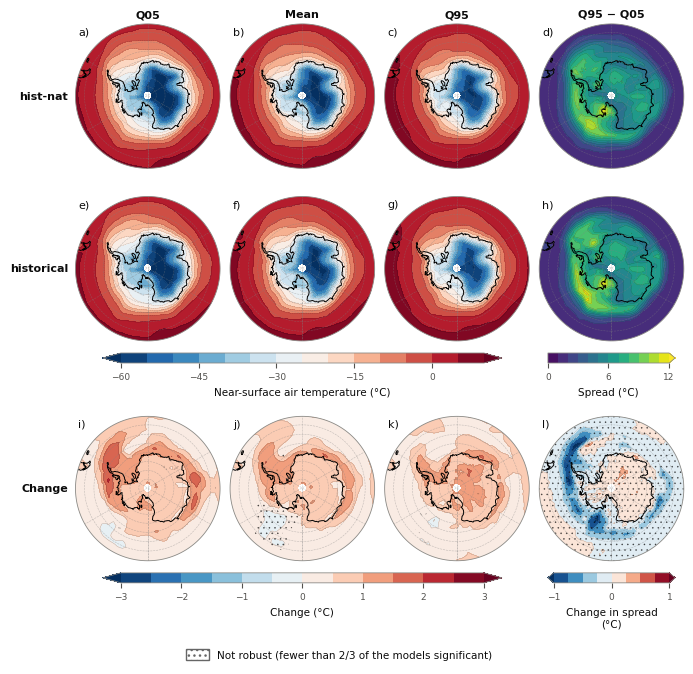

In [32]:
panels = fr.block_grid(
    [fr.Block({'hist-nat': median_hist_nat_fields_ds.sel(season=WINTER),
               'historical': median_experiment_fields_ds.sel(experiment='historical', season=WINTER)},
              scales=[scales.temperature, scales.temperature, scales.temperature, scales.spread]),
     fr.Block({'Change': median_change_fields_ds.sel(experiment='historical', season=WINTER)},
              scales=[scales.change, scales.change, scales.change, scales.spread_change],
              not_significant={'Change': not_robust_ds.sel(experiment='historical', season=WINTER)})],
    width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)

In [33]:
fr.save(panels, PAPER_DIR, f'fig1_distribution_historical_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig1_distribution_historical_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig1_distribution_historical_JJA.png')]

**Figure 2. How each forcing changes the distribution of winter (JJA) temperature.** Multi-model median change, 1993–2013 against hist-nat, of the 5th percentile, the mean, the 95th percentile and the width (Q95 − Q05) of the internal variability, for each single forcing (rows) and all forcings together (historical). Dots as in Fig. 1.

In [34]:
#(t): The changes in WINTER, every forcing
winter_changes_ds = median_change_fields_ds.sel(experiment=EXPERIMENTS, season=WINTER)
winter_changes_ds

<xarray.Dataset> Size: 324kB
Dimensions:     (lat: 20, lon: 144, experiment: 4)
Coordinates:
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    season      <U3 12B 'JJA'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
Data variables:
    Q05         (lat, lon, experiment) float64 92kB 1.355 -0.3267 ... 0.4753
    Mean        (lat, lon, experiment) float32 46kB 1.446 -0.3345 ... 0.4804
    Q95         (lat, lon, experiment) float64 92kB 1.392 -0.4141 ... 0.6954
    Q95 − Q05   (lat, lon, experiment) float64 92kB -0.002845 ... -0.03072

In [35]:
#(t): and where they are not robust
winter_not_robust_ds = not_robust_ds.sel(experiment=EXPERIMENTS, season=WINTER)

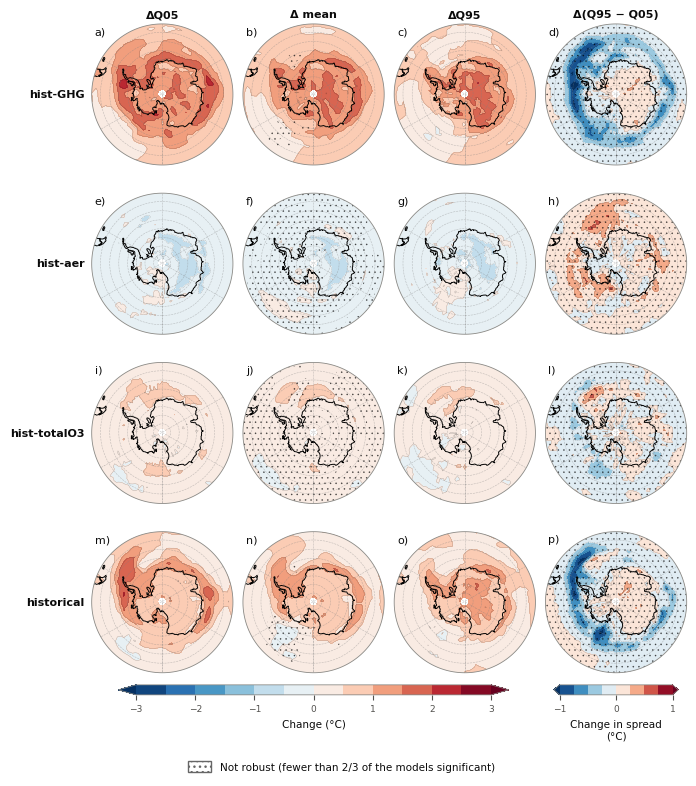

In [36]:
panels = fr.block_grid(
    [fr.Block({experiment: winter_changes_ds.sel(experiment=experiment) for experiment in EXPERIMENTS},
              scales=[scales.change, scales.change, scales.change, scales.spread_change],
              not_significant={experiment: winter_not_robust_ds.sel(experiment=experiment) for experiment in EXPERIMENTS})],
    column_titles=['ΔQ05', 'Δ mean', 'ΔQ95', 'Δ(Q95 − Q05)'],
    width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)

In [37]:
fr.save(panels, PAPER_DIR, f'fig2_forcings_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig2_forcings_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig2_forcings_JJA.png')]

**Figure 3. As Fig. 2, in summer (DJF).**

In [38]:
#(t): The changes in SUMMER, every forcing
summer_changes_ds = median_change_fields_ds.sel(experiment=EXPERIMENTS, season=SUMMER)
summer_changes_ds

<xarray.Dataset> Size: 324kB
Dimensions:     (lat: 20, lon: 144, experiment: 4)
Coordinates:
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    season      <U3 12B 'DJF'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
Data variables:
    Q05         (lat, lon, experiment) float64 92kB 1.5 -0.4054 ... 0.7462
    Mean        (lat, lon, experiment) float32 46kB 1.55 -0.4011 ... 0.7788
    Q95         (lat, lon, experiment) float64 92kB 1.475 -0.4708 ... 0.9707
    Q95 − Q05   (lat, lon, experiment) float64 92kB -0.04459 ... 0.02972

In [39]:
#(t): and where they are not robust
summer_not_robust_ds = not_robust_ds.sel(experiment=EXPERIMENTS, season=SUMMER)

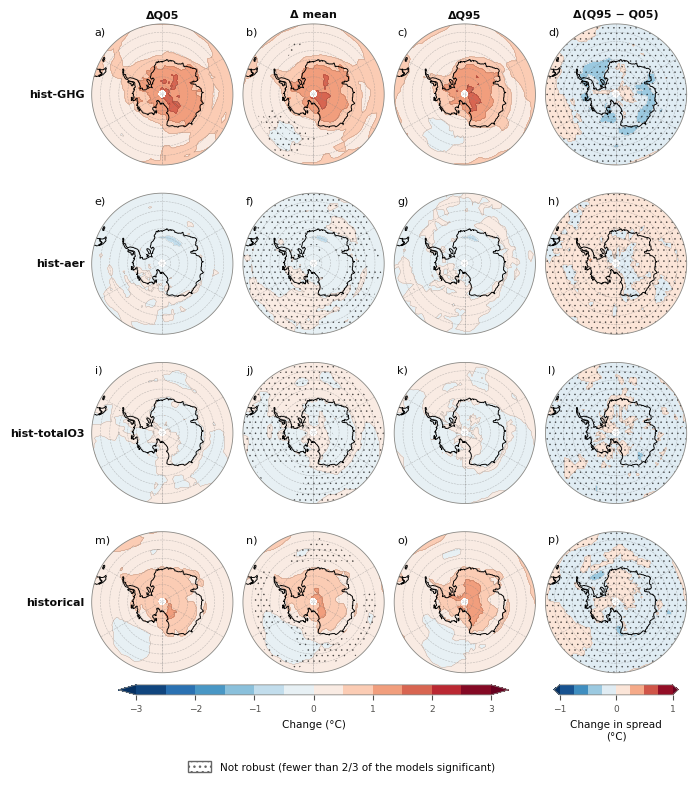

In [40]:
panels = fr.block_grid(
    [fr.Block({experiment: summer_changes_ds.sel(experiment=experiment) for experiment in EXPERIMENTS},
              scales=[scales.change, scales.change, scales.change, scales.spread_change],
              not_significant={experiment: summer_not_robust_ds.sel(experiment=experiment) for experiment in EXPERIMENTS})],
    column_titles=['ΔQ05', 'Δ mean', 'ΔQ95', 'Δ(Q95 − Q05)'],
    width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)

In [41]:
fr.save(panels, PAPER_DIR, f'fig3_forcings_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig3_forcings_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig3_forcings_DJF.png')]

**Figure 4. Where the mean and the variability have changed together.** For each forcing (columns) in summer (DJF) and winter (JJA): the robust change in the mean (rows of the key: lower, none, higher) combined with the robust change in the width of the internal variability (columns of the key: narrower, none, wider). A change is robust where at least two-thirds of the models have a significant change of that sign (tests as in Fig. 1).

In [42]:
#(t): The robust joint class, every forcing, in summer and winter
seasons_class_da = robust_joint_class_da.sel(experiment=EXPERIMENTS, season=[SUMMER, WINTER])
seasons_class_da

<xarray.DataArray (lat: 20, lon: 144, season: 2, experiment: 4)> Size: 184kB
7.0 1.0 4.0 7.0 7.0 1.0 4.0 7.0 7.0 1.0 ... 7.0 7.0 1.0 7.0 7.0 7.0 1.0 4.0 7.0
Coordinates:
  * season      (season) object 16B 'DJF' 'JJA'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5

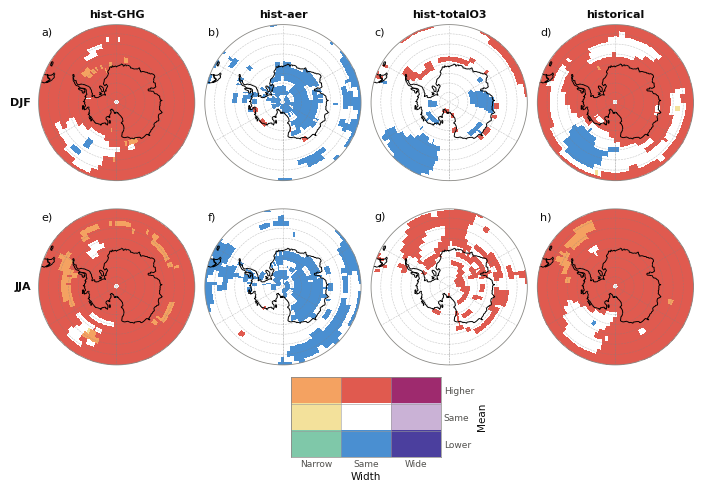

In [43]:
panels = fr.map_grid(
    seasons_class_da, scales.joint, row_dim='season', col_dim='experiment',
    width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
)

In [44]:
fr.save(panels, PAPER_DIR, 'fig4_joint_change')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig4_joint_change.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig4_joint_change.png')]

**Figure 5. The change in the mean and in the width, averaged south of 60°S.** Each model's area-mean change (markers; colour: forcing) in each season, 1993–2013 against hist-nat; bars: the multi-model median. Top: the mean; bottom: the width Q95 − Q05 of the internal variability.

In [45]:
#(t): Area means south of 60°S of every model's changes
change_regional_ds = rc.regional_mean(change_ds.sel(experiment=EXPERIMENTS), lat_max=-60, mean_test=MEAN_TEST)
change_regional_ds

<xarray.Dataset> Size: 7kB
Dimensions:                  (model: 6, season: 4, experiment: 4)
Coordinates:
  * model                    (model) object 48B 'CanESM5' ... 'NorESM2-LM'
  * season                   (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * experiment               (experiment) object 32B 'hist-GHG' ... 'historical'
Data variables:
    mean_change              (season, model, experiment) float64 768B 1.182 ....
    width_change             (season, model, experiment) float64 768B -0.2839...
    upper_tail_change        (season, model, experiment) float64 768B -0.1379...
    lower_tail_change        (season, model, experiment) float64 768B -0.146 ...
    tail_asymmetry           (season, model, experiment) float64 768B 0.00808...
    fraction_neither         (season, model, experiment) float64 768B 0.00263...
    fraction_mean_only       (season, model, experiment) float64 768B 0.6879 ...
    fraction_width_only      (season, model, experiment) float64 768B 0.00054...
    fraction_mean_and_width  (season, model, experiment) float64 768B 0.3089 ...
Attributes: (3)

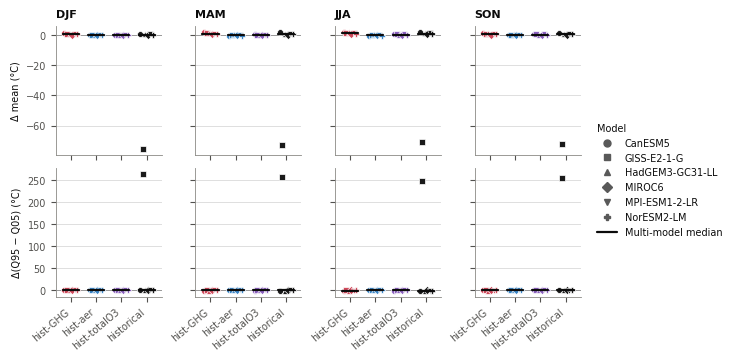

In [46]:
panels = fr.forcing_dots(
    change_regional_ds,
    {'mean_change': f'Δ mean ({UNITS})', 'width_change': f'Δ(Q95 − Q05) ({UNITS})'},
    columns=SEASONS, experiments=EXPERIMENTS, style=STYLE, panel_size=(1.45, 1.5), width=WIDTH,
)

In [47]:
fr.save(panels, PAPER_DIR, 'fig5_area_means')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig5_area_means.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig5_area_means.png')]

**Figure 6. The change at each latitude in winter (JJA).** Zonal-mean change, 1993–2013 against hist-nat, for each forcing (rows) and every model (lines): the mean; the low extremes Δ(Q05 − Q50) and the high extremes Δ(Q95 − Q50) of the internal variability, each measured from the median; and the width Δ(Q95 − Q05), the high minus the low. Dots: significant zonal-mean change in that model (the mean: member-block test; the width: hist-nat bootstrap; p < 0.05). Dashed: the sea-ice edge (equivalent latitude) of each model in 1993–2013. After Bracegirdle et al. (2024), Fig. 2.

In [48]:
#(t): The four columns, zonally averaged, with the zonal tests
zonal_ds = zonal.zonal_summary(change_ds, zonal_mean_ds, zonal_width_ds)
zonal_ds

<xarray.Dataset> Size: 96kB
Dimensions:              (model: 6, season: 4, lat: 20, experiment: 4)
Coordinates:
  * model                (model) object 48B 'CanESM5' ... 'NorESM2-LM'
  * season               (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat                  (lat) float64 160B -87.5 -85.0 -82.5 ... -42.5 -40.0
  * experiment           (experiment) object 32B 'hist-GHG' ... 'historical'
Data variables:
    mean_change          (lat, season, model, experiment) float32 8kB 2.494 ....
    low_extreme_change   (lat, season, model, experiment) float64 15kB 0.0855...
    high_extreme_change  (lat, season, model, experiment) float64 15kB -0.090...
    width_change         (lat, season, model, experiment) float64 15kB -0.176...
    mean_pvalue          (lat, season, model, experiment) float64 15kB 0.0003...
    width_pvalue         (lat, season, model, experiment) float64 15kB 0.3796...
    hist_nat_width       (lat, season, model) float64 4kB 3.361 4.331 ... 1.213
    null_lower           (lat, season, model) float64 4kB -0.319 ... -0.0616
    null_upper           (lat, season, model) float64 4kB 0.2284 ... 0.02178
Attributes: (2)

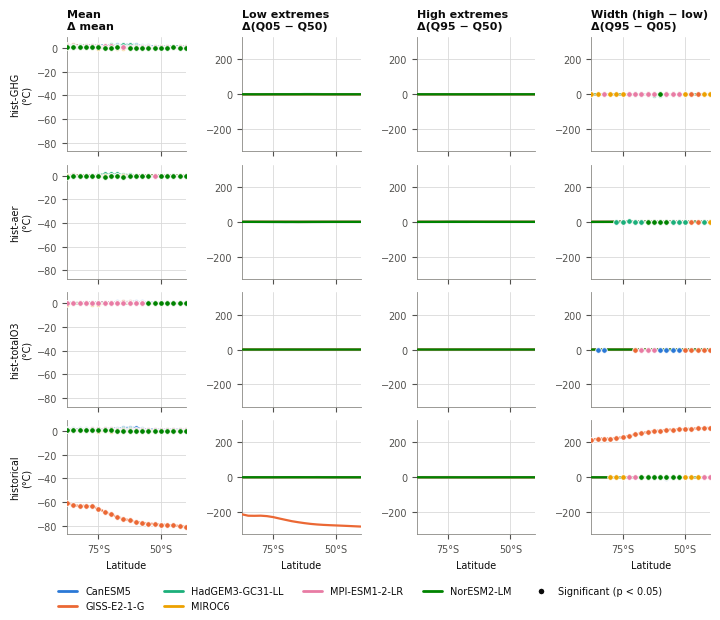

In [49]:
fig, axes = zp.zonal_change_grid(zonal_ds, WINTER, rows='experiment', lines='model', row_values=EXPERIMENTS,
                                 edges=ice_edges_da, units=UNITS, title='', panel_size=(1.55, 1.15),
                                 rc_params=STYLE.rc, width=WIDTH)

In [50]:
fr.save(fig, PAPER_DIR, f'fig6_zonal_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig6_zonal_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/fig6_zonal_JJA.png')]

## Supplementary figures

**Figure S1. As Fig. 1, in summer (DJF).**

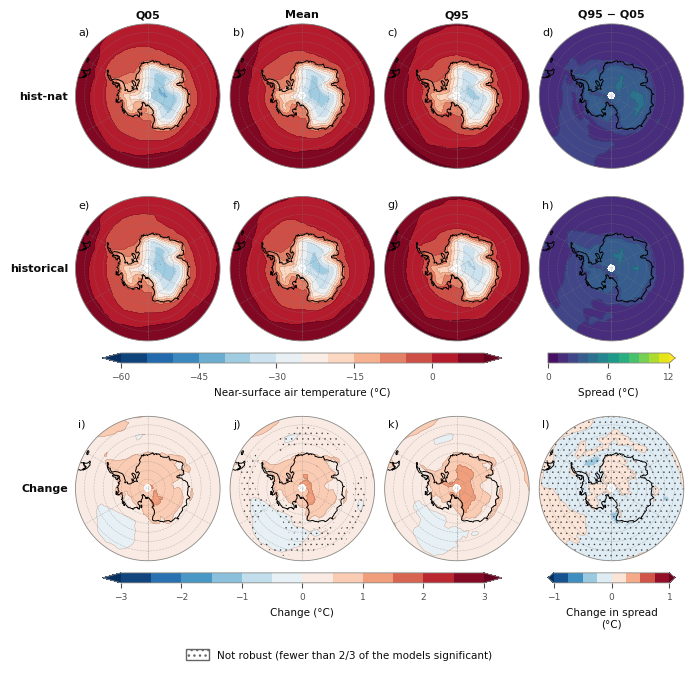

In [51]:
panels = fr.block_grid(
    [fr.Block({'hist-nat': median_hist_nat_fields_ds.sel(season=SUMMER),
               'historical': median_experiment_fields_ds.sel(experiment='historical', season=SUMMER)},
              scales=[scales.temperature, scales.temperature, scales.temperature, scales.spread]),
     fr.Block({'Change': median_change_fields_ds.sel(experiment='historical', season=SUMMER)},
              scales=[scales.change, scales.change, scales.change, scales.spread_change],
              not_significant={'Change': not_robust_ds.sel(experiment='historical', season=SUMMER)})],
    width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label='Not robust (fewer than 2/3 of the models significant)',
)

In [52]:
fr.save(panels, PAPER_DIR, f'figS1_distribution_historical_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS1_distribution_historical_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS1_distribution_historical_DJF.png')]

**Figure S2. Every model's historical change in the distribution of winter (JJA) temperature.** As the bottom row of Fig. 1, for each model (rows), with each model's joint class (as in Fig. 4, from that model's own tests). Dots: not significant in that model (p ≥ 0.05).

In [53]:
#(t): Every model, historical, WINTER: the changes
winter_model_changes_ds = change_fields_ds.sel(experiment='historical', season=WINTER)
winter_model_changes_ds

<xarray.Dataset> Size: 485kB
Dimensions:     (model: 6, lat: 20, lon: 144)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    season      <U3 12B 'JJA'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
    experiment  <U10 40B 'historical'
Data variables:
    Q05         (lat, lon, model) float64 138kB 1.144 -215.7 ... 0.7905 0.4136
    Mean        (lat, lon, model) float32 69kB 1.275 -61.18 ... 0.8211 0.4294
    Q95         (lat, lon, model) float64 138kB 1.215 1.337 ... 0.824 0.4293
    Q95 − Q05   (lat, lon, model) float64 138kB 0.03984 217.2 ... -0.005893

In [54]:
#(t): where they are not significant
winter_model_not_significant_ds = change_not_significant_ds.sel(experiment='historical', season=WINTER)

In [55]:
#(t): and the joint class
winter_model_class_da = model_joint_class_da.sel(experiment='historical', season=WINTER)

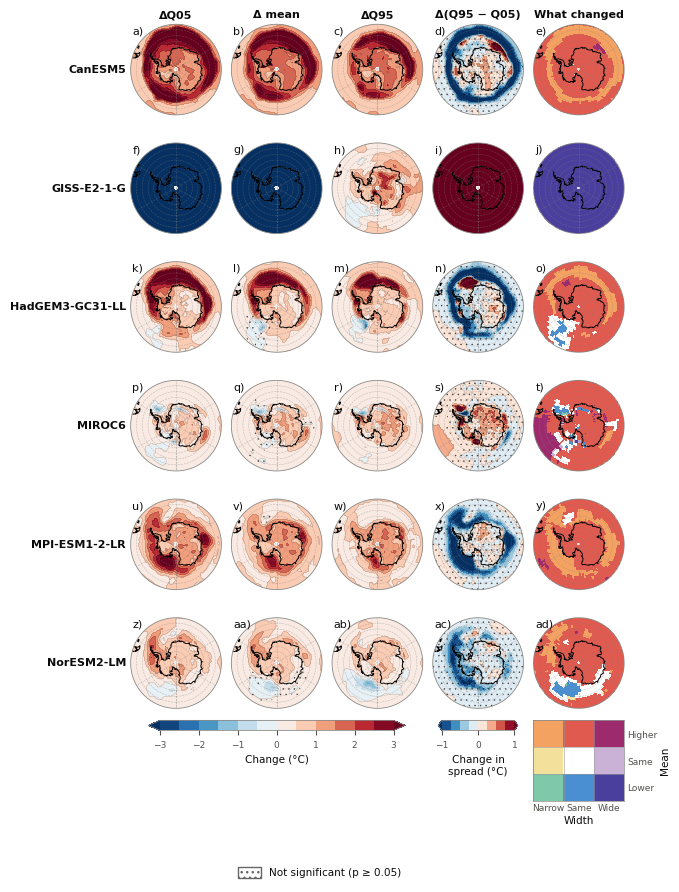

In [56]:
panels = fr.field_grid(
    [fr.Column(winter_model_changes_ds['Q05'], scales.change, 'ΔQ05'),
     fr.Column(winter_model_changes_ds['Mean'], scales.change, 'Δ mean',
               not_significant=winter_model_not_significant_ds['Mean']),
     fr.Column(winter_model_changes_ds['Q95'], scales.change, 'ΔQ95'),
     fr.Column(winter_model_changes_ds['Q95 − Q05'], scales.spread_change, 'Δ(Q95 − Q05)',
               not_significant=winter_model_not_significant_ds['Q95 − Q05']),
     fr.Column(winter_model_class_da, scales.joint, 'What changed')],
    row_dim='model', width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label=f'Not significant (p ≥ {ALPHA:g})',
)

In [57]:
fr.save(panels, PAPER_DIR, f'figS2_models_historical_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS2_models_historical_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS2_models_historical_JJA.png')]

**Figure S3. As Fig. S2, in summer (DJF).**

In [58]:
#(t): Every model, historical, SUMMER: the changes
summer_model_changes_ds = change_fields_ds.sel(experiment='historical', season=SUMMER)
summer_model_changes_ds

<xarray.Dataset> Size: 485kB
Dimensions:     (model: 6, lat: 20, lon: 144)
Coordinates:
  * model       (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
    season      <U3 12B 'DJF'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
    experiment  <U10 40B 'historical'
Data variables:
    Q05         (lat, lon, model) float64 138kB 1.555 -240.2 ... 0.957 0.6435
    Mean        (lat, lon, model) float32 69kB 1.726 -68.08 ... 1.018 0.5075
    Q95         (lat, lon, model) float64 138kB 1.702 1.463 ... 1.012 0.5114
    Q95 − Q05   (lat, lon, model) float64 138kB 0.01211 241.8 ... -0.1394

In [59]:
#(t): where they are not significant
summer_model_not_significant_ds = change_not_significant_ds.sel(experiment='historical', season=SUMMER)

In [60]:
#(t): and the joint class
summer_model_class_da = model_joint_class_da.sel(experiment='historical', season=SUMMER)

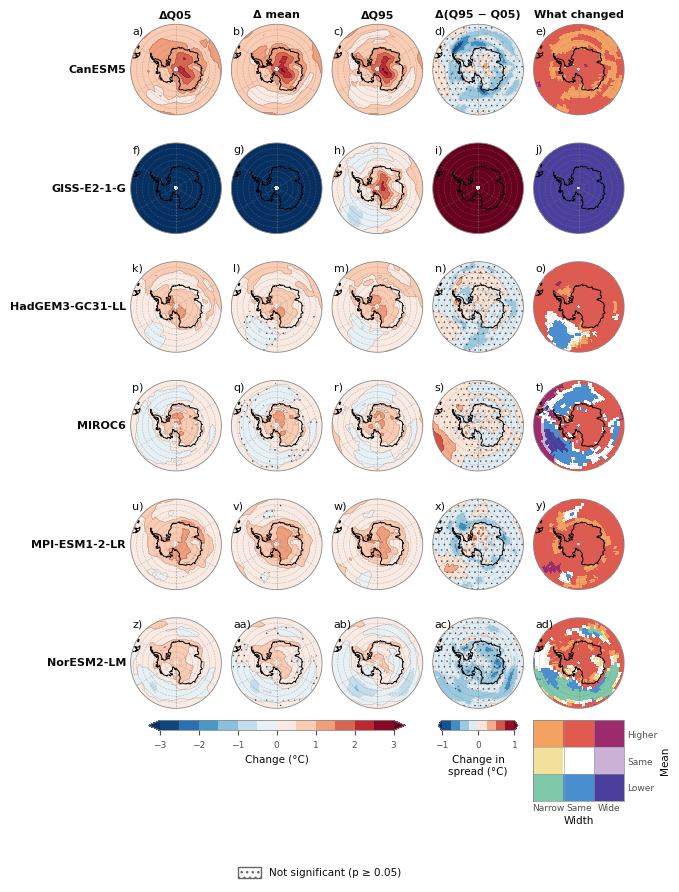

In [61]:
panels = fr.field_grid(
    [fr.Column(summer_model_changes_ds['Q05'], scales.change, 'ΔQ05'),
     fr.Column(summer_model_changes_ds['Mean'], scales.change, 'Δ mean',
               not_significant=summer_model_not_significant_ds['Mean']),
     fr.Column(summer_model_changes_ds['Q95'], scales.change, 'ΔQ95'),
     fr.Column(summer_model_changes_ds['Q95 − Q05'], scales.spread_change, 'Δ(Q95 − Q05)',
               not_significant=summer_model_not_significant_ds['Q95 − Q05']),
     fr.Column(summer_model_class_da, scales.joint, 'What changed')],
    row_dim='model', width=WIDTH, height=HEIGHT, style=STYLE, tag=True,
    not_significant_label=f'Not significant (p ≥ {ALPHA:g})',
)

In [62]:
fr.save(panels, PAPER_DIR, f'figS3_models_historical_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS3_models_historical_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS3_models_historical_DJF.png')]

**Figures S4–S7. How many models have a significant change.** At each grid point, the number of models with a significant increase (top rows, red) and decrease (bottom rows, blue) in the mean (S4: DJF, S5: JJA) and in the width Q95 − Q05 (S6: DJF, S7: JJA), for each forcing. Tests as in Fig. 1.

In [63]:
#(t): The counts: the mean
mean_counts_da = sig.significant_counts(change_fields_ds['Mean'], change_significant_ds['Mean'])
mean_counts_da

<xarray.DataArray 'Mean' (direction: 2, lat: 20, lon: 144, season: 4,
                          experiment: 4)> Size: 737kB
6 0 3 4 5 0 2 4 5 0 2 4 5 0 4 4 5 0 3 ... 4 0 1 0 4 0 1 0 5 2 1 0 5 2 1 0 4 1 1
Coordinates:
  * season      (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * lat         (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * lon         (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * direction   (direction) <U8 64B 'increase' 'decrease'

In [64]:
#(t): and the width
width_counts_da = sig.significant_counts(change_fields_ds['Q95 − Q05'], change_significant_ds['Q95 − Q05'])

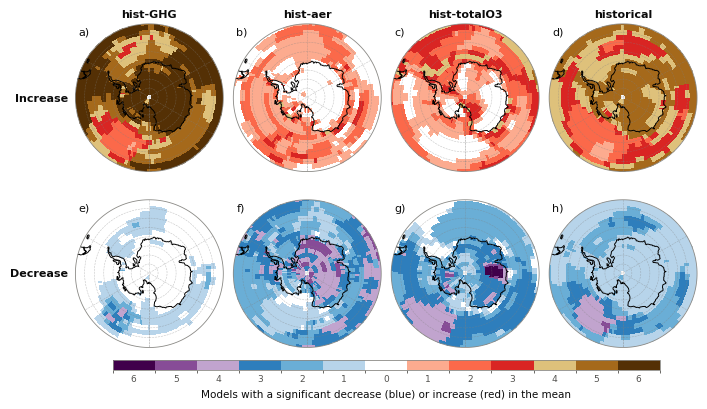

In [65]:
panels = fr.count_grid(mean_counts_da.sel(experiment=EXPERIMENTS, season=SUMMER), N_MODELS, title=None,
                       label='Models with a significant decrease (blue) or increase (red) in the mean',
                       row_labels={'increase': 'Increase', 'decrease': 'Decrease'},
                       width=WIDTH, height=HEIGHT, style=STYLE, tag=True)

In [66]:
fr.save(panels, PAPER_DIR, f'figS4_mean_counts_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS4_mean_counts_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS4_mean_counts_DJF.png')]

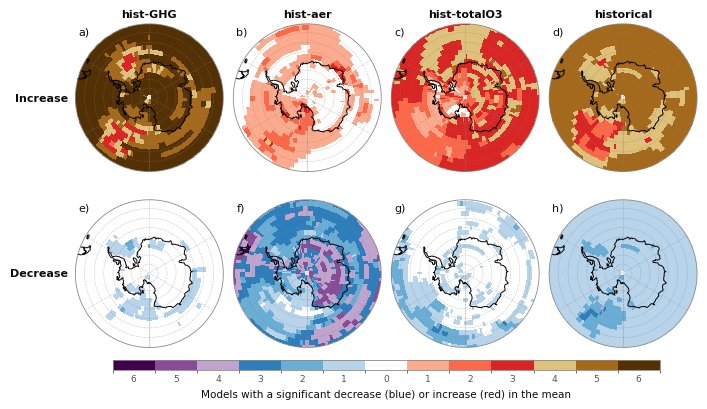

In [67]:
panels = fr.count_grid(mean_counts_da.sel(experiment=EXPERIMENTS, season=WINTER), N_MODELS, title=None,
                       label='Models with a significant decrease (blue) or increase (red) in the mean',
                       row_labels={'increase': 'Increase', 'decrease': 'Decrease'},
                       width=WIDTH, height=HEIGHT, style=STYLE, tag=True)

In [68]:
fr.save(panels, PAPER_DIR, f'figS5_mean_counts_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS5_mean_counts_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS5_mean_counts_JJA.png')]

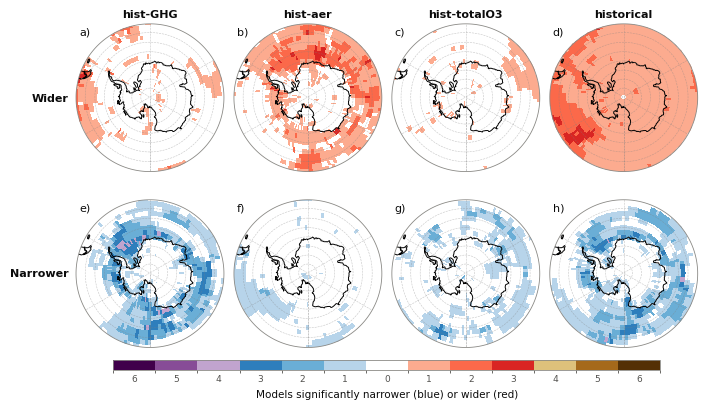

In [69]:
panels = fr.count_grid(width_counts_da.sel(experiment=EXPERIMENTS, season=SUMMER), N_MODELS, title=None,
                       label='Models significantly narrower (blue) or wider (red)',
                       row_labels={'increase': 'Wider', 'decrease': 'Narrower'},
                       width=WIDTH, height=HEIGHT, style=STYLE, tag=True)

In [70]:
fr.save(panels, PAPER_DIR, f'figS6_width_counts_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS6_width_counts_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS6_width_counts_DJF.png')]

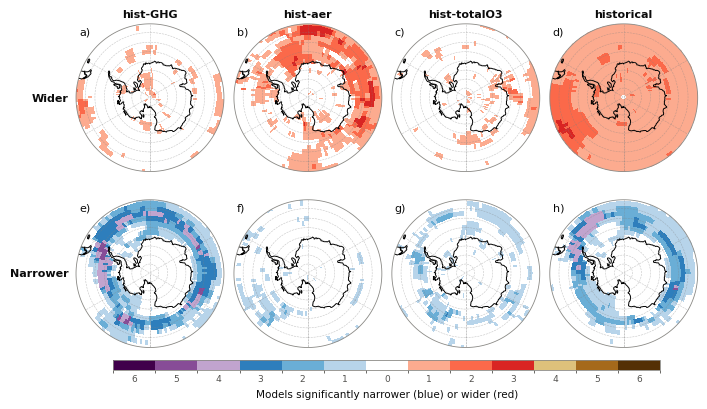

In [71]:
panels = fr.count_grid(width_counts_da.sel(experiment=EXPERIMENTS, season=WINTER), N_MODELS, title=None,
                       label='Models significantly narrower (blue) or wider (red)',
                       row_labels={'increase': 'Wider', 'decrease': 'Narrower'},
                       width=WIDTH, height=HEIGHT, style=STYLE, tag=True)

In [72]:
fr.save(panels, PAPER_DIR, f'figS7_width_counts_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS7_width_counts_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS7_width_counts_JJA.png')]

**Figures S8, S9. Signal to noise.** |S/N| in 2003 (the centre of 1993–2013) for every model (rows) and forcing (columns), in DJF (S8) and JJA (S9): the forced response minus hist-nat's, over the pooled year-to-year standard deviation, whichever way the shift goes. It measures how far apart the two distributions have moved: yellow below 1, orange from 1 to 2, red above 2.

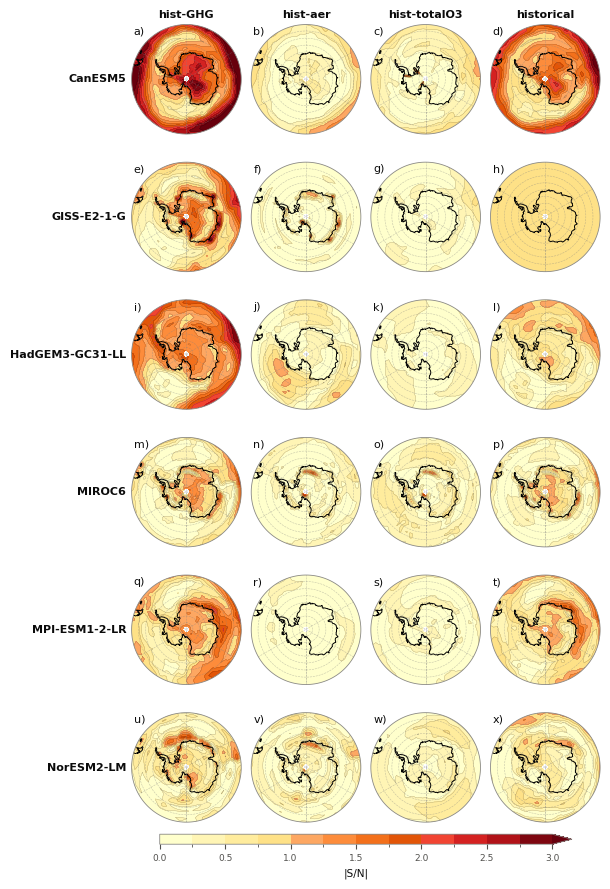

In [73]:
panels = fr.map_grid(abs_sn_final_da.sel(experiment=EXPERIMENTS, season=SUMMER), scales.sn, width=WIDTH, height=HEIGHT, style=STYLE,
                     tag=True)

In [74]:
fr.save(panels, PAPER_DIR, f'figS8_sn_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS8_sn_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS8_sn_DJF.png')]

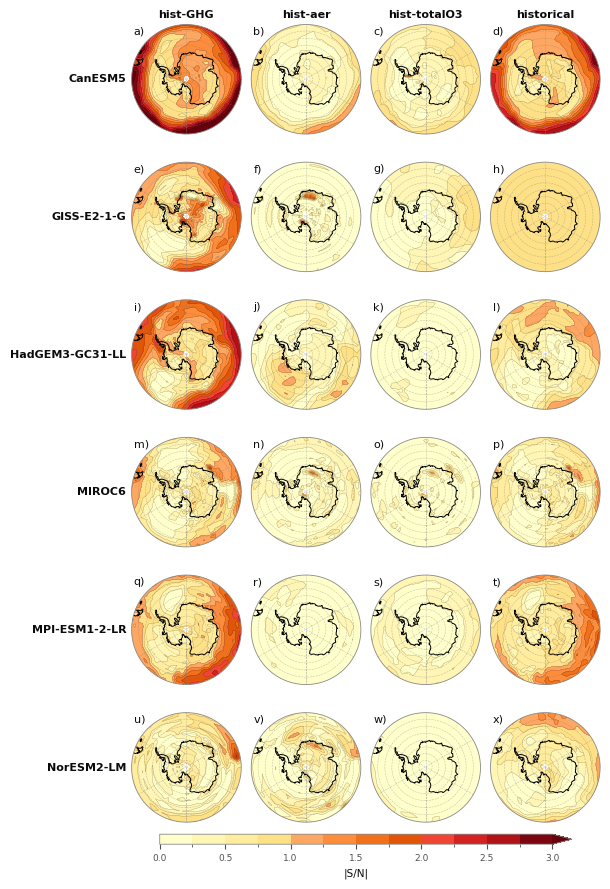

In [75]:
panels = fr.map_grid(abs_sn_final_da.sel(experiment=EXPERIMENTS, season=WINTER), scales.sn, width=WIDTH, height=HEIGHT, style=STYLE,
                     tag=True)

In [76]:
fr.save(panels, PAPER_DIR, f'figS9_sn_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS9_sn_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS9_sn_JJA.png')]

**Figure S10. The change at every percentile.** Area mean (south of 40°S) of the change in every 5th percentile, 1993–2013 against hist-nat's whole record, every model (lines), in DJF (top) and JJA (bottom). A flat line is a pure shift; a rising line, a widening distribution.

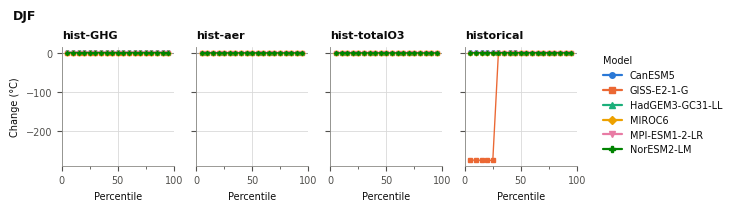

In [77]:
panels = fr.quantile_curves(quantile_curve_da.sel(experiment=EXPERIMENTS, season=SUMMER), title=f'{SUMMER}', units=UNITS,
                            style=STYLE, panel_size=(1.45, 1.4), width=WIDTH)

In [78]:
fr.save(panels, PAPER_DIR, f'figS10a_quantile_curves_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS10a_quantile_curves_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS10a_quantile_curves_DJF.png')]

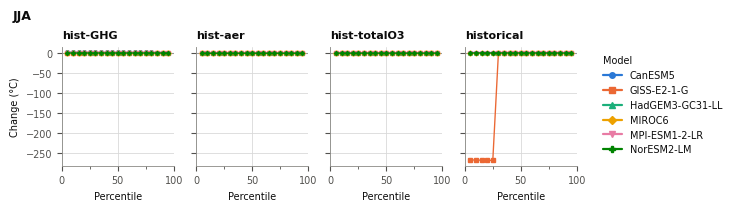

In [79]:
panels = fr.quantile_curves(quantile_curve_da.sel(experiment=EXPERIMENTS, season=WINTER), title=f'{WINTER}', units=UNITS,
                            style=STYLE, panel_size=(1.45, 1.4), width=WIDTH)

In [80]:
fr.save(panels, PAPER_DIR, f'figS10b_quantile_curves_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS10b_quantile_curves_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS10b_quantile_curves_JJA.png')]

**Figure S11. Additivity.** For each model (rows), winter (JJA): the sum of the four single-forcing changes (hist-nat, hist-GHG, hist-aer, hist-totalO3), the historical change, and the residual (historical minus the sum), each experiment's final 21 years against its own 1850–1900.

In [81]:
#(t): Every term: each part, their sum, historical and the residual
additivity_ds = rc.additivity(own_changes_da)
additivity_ds

<xarray.Dataset> Size: 4MB
Dimensions:   (lon: 144, season: 4, model: 6, lat: 20, term: 7)
Coordinates:
  * lon       (lon) float64 1kB -180.0 -177.5 -175.0 ... 172.5 175.0 177.5
  * season    (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * model     (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat       (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * term      (term) <U12 336B 'hist-nat' 'hist-GHG' ... 'historical' 'residual'
Data variables:
    response  (term, lat, lon, season, model) float32 2MB -0.03037 ... -0.09998
    fraction  (term, lat, lon, season, model) float32 2MB -0.0194 ... -0.2967
Attributes: (1)

In [82]:
#(t): The sum, historical and the residual, every model, WINTER
winter_additivity_da = additivity_ds['response'].sel(season=WINTER, term=['sum of parts', 'historical', 'residual'])
winter_additivity_da

<xarray.DataArray 'response' (term: 3, lat: 20, lon: 144, model: 6)> Size: 207kB
1.151 1.161 1.876 0.5738 0.9535 ... -0.3052 -0.3622 -0.05037 -0.1307 -0.03658
Coordinates:
  * lon      (lon) float64 1kB -180.0 -177.5 -175.0 -172.5 ... 172.5 175.0 177.5
    season   <U3 12B 'JJA'
  * model    (model) object 48B 'CanESM5' 'GISS-E2-1-G' ... 'NorESM2-LM'
  * lat      (lat) float64 160B -87.5 -85.0 -82.5 -80.0 ... -45.0 -42.5 -40.0
  * term     (term) <U12 144B 'sum of parts' 'historical' 'residual'

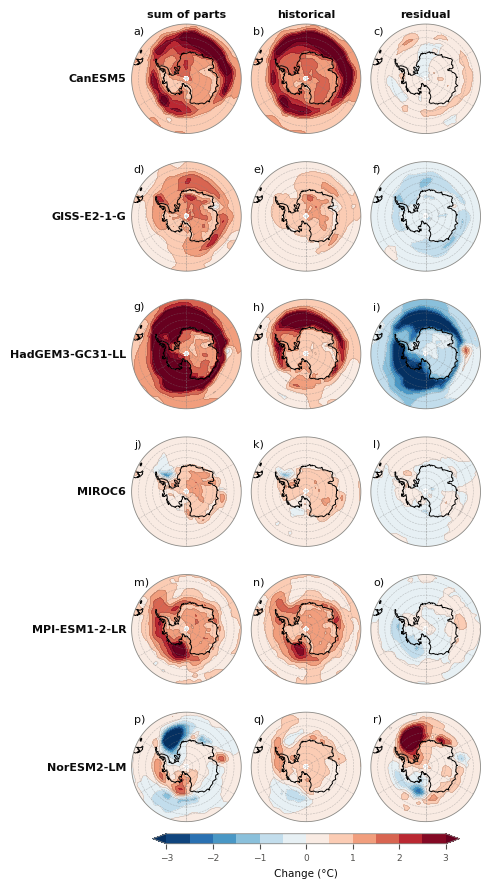

In [83]:
panels = fr.map_grid(winter_additivity_da, scales.change, row_dim='model', col_dim='term', width=WIDTH, height=HEIGHT,
                     style=STYLE, tag=True)

In [84]:
fr.save(panels, PAPER_DIR, f'figS11_additivity_{WINTER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS11_additivity_JJA.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS11_additivity_JJA.png')]

**Figure S12. As Fig. 6, in summer (DJF).**

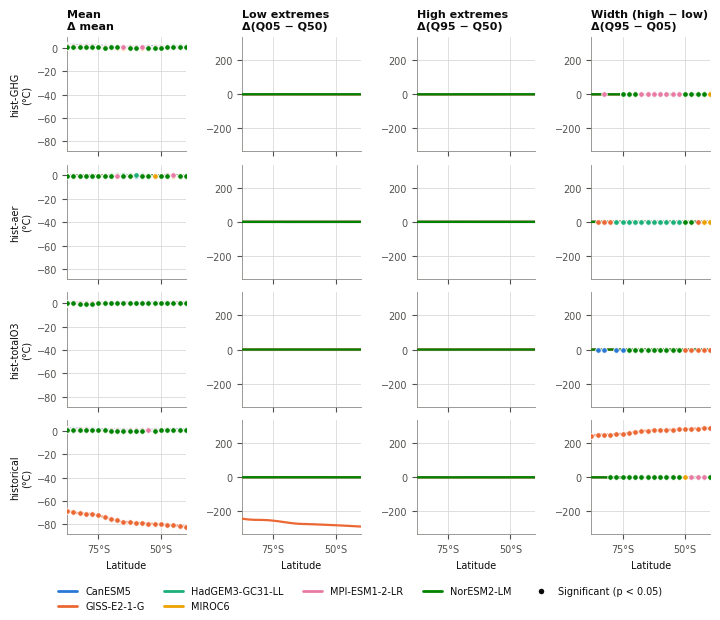

In [85]:
fig, axes = zp.zonal_change_grid(zonal_ds, SUMMER, rows='experiment', lines='model', row_values=EXPERIMENTS,
                                 edges=ice_edges_da, units=UNITS, title='', panel_size=(1.55, 1.15),
                                 rc_params=STYLE.rc, width=WIDTH)

In [86]:
fr.save(fig, PAPER_DIR, f'figS12_zonal_{SUMMER}')

[PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS12_zonal_DJF.pdf'),
 PosixPath('/home/users/aborow/ExtAnt-initial/figures/tas/paper/figS12_zonal_DJF.png')]

## What was saved

In [87]:
pd.Series(sorted(path.name for path in PAPER_DIR.glob('*.pdf')), name='saved in ' + str(PAPER_DIR))

0      fig1_distribution_historical_JJA.pdf
1                     fig2_forcings_JJA.pdf
2                     fig3_forcings_DJF.pdf
3                     fig4_joint_change.pdf
4                       fig5_area_means.pdf
5                        fig6_zonal_JJA.pdf
6           figS10a_quantile_curves_DJF.pdf
7           figS10b_quantile_curves_JJA.pdf
8                 figS11_additivity_JJA.pdf
9                      figS12_zonal_DJF.pdf
10    figS1_distribution_historical_DJF.pdf
11          figS2_models_historical_JJA.pdf
12          figS3_models_historical_DJF.pdf
13                figS4_mean_counts_DJF.pdf
14                figS5_mean_counts_JJA.pdf
15               figS6_width_counts_DJF.pdf
16               figS7_width_counts_JJA.pdf
17                         figS8_sn_DJF.pdf
18                         figS9_sn_JJA.pdf
Name: saved in /home/users/aborow/ExtAnt-initial/figures/tas/paper, dtype: object